<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Distance &amp; Codependence
    </h1>
  </div>
</div>

Correlation only sees **linear** dependence. To cluster assets or screen features
by genuine codependence we need measures that capture nonlinear structure: mutual
information (MI) and distance correlation. De Prado's **binned MI** estimates the
joint density on a fixed grid, so its bias and variance grow as the sample shrinks
relative to the bin count, and the answer depends on an arbitrary binning.

The **KSG** estimator (Kraskov-Stogbauer-Grassberger 2004) uses adaptive
$k$-nearest-neighbour distances instead of bins, so it is far less biased on short,
noisy, or nonlinear samples. **Distance correlation** (Szekely-Rizzo-Bakirov 2007)
is a tuning-free index that is zero if and only if the variables are independent.
We show where KSG clearly beats binned MI, and where it does not.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# --- Local source bootstrap -------------------------------------------------
# The admitted Stage-1 methods demonstrated here are merged in the RiskLabAI.py
# source tree but not yet in a tagged PyPI release, so we put the local source
# ahead of any installed copy. Once these ship in a release this block is a
# no-op and a plain `pip install RiskLabAI` is enough.
import sys
from pathlib import Path
_cands = [p / "RiskLabAI.py" for p in [Path.cwd(), *Path.cwd().parents]]
_cands.append(Path(r"C:/risklab/risklabai/RiskLabAI.py"))
for _src in _cands:
    if (_src / "RiskLabAI" / "__init__.py").exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({  # theme-adaptive figures: transparent bg + neutral-gray foreground
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "text.color": "#888888", "axes.labelcolor": "#888888", "axes.titlecolor": "#888888",
    "axes.edgecolor": "#888888", "xtick.color": "#888888", "ytick.color": "#888888",
    "grid.color": "#888888", "grid.alpha": 0.3, "legend.framealpha": 0.0,
})


In [2]:
from RiskLabAI.data.distance import (
    calculate_mutual_information,   # baseline: binned (histogram) mutual information
    ksg_mutual_information,         # kNN mutual information (Kraskov et al. 2004)
    distance_correlation,          # tuning-free nonlinear dependence index
)

LOG2 = np.log(2)  # KSG and binned MI return nats; divide by ln 2 for bits

def true_gaussian_mi_bits(rho):
    """Exact mutual information of a bivariate Gaussian with correlation rho, in bits."""
    return -0.5 * np.log(1 - rho ** 2) / LOG2

## 1. A linear benchmark with known mutual information

For a bivariate Gaussian with correlation $\rho$ the mutual information is known in
closed form. On this **linear** problem the histogram estimator is already well
behaved, so KSG offers no free lunch: both land near the truth. This is the regime
where binned MI is fine.

In [3]:
rho, truth = 0.7, true_gaussian_mi_bits(0.7)
print(f"rho = {rho}   ->   true MI = {truth:.3f} bits")
for n in (200, 1000):
    ksg, binned = [], []
    for s in range(15):
        r = np.random.default_rng(s)
        z = r.standard_normal(n)
        x = z
        y = rho * z + np.sqrt(1 - rho ** 2) * r.standard_normal(n)
        ksg.append(ksg_mutual_information(x, y) / LOG2)
        binned.append(calculate_mutual_information(x, y) / LOG2)
    ksg, binned = np.array(ksg), np.array(binned)
    rmse = lambda a: np.sqrt(np.mean((a - truth) ** 2))
    print(f"n={n:5d}:  KSG mean={ksg.mean():.3f} (RMSE {rmse(ksg):.3f})   "
          f"binned mean={binned.mean():.3f} (RMSE {rmse(binned):.3f})")

rho = 0.7   ->   true MI = 0.486 bits
n=  200:  KSG mean=0.484 (RMSE 0.085)   binned mean=0.512 (RMSE 0.055)
n= 1000:  KSG mean=0.507 (RMSE 0.045)   binned mean=0.489 (RMSE 0.034)


## 2. Where binned MI breaks: a nonlinear monotone map

Mutual information is invariant under any monotone transform of a variable, so if
we replace the Gaussian $z$ by $y = z^3$ the true MI is unchanged. But the cubic
stretches the histogram bins unevenly, so **binned MI collapses** while **KSG**,
being distance-based, stays close to the truth. This is the regime the KSG
estimator is for.

true MI (invariant under the monotone map) = 0.486 bits
KSG   : mean = 0.444   RMSE = 0.056
binned: mean = 0.274   RMSE = 0.219   (badly underestimated)


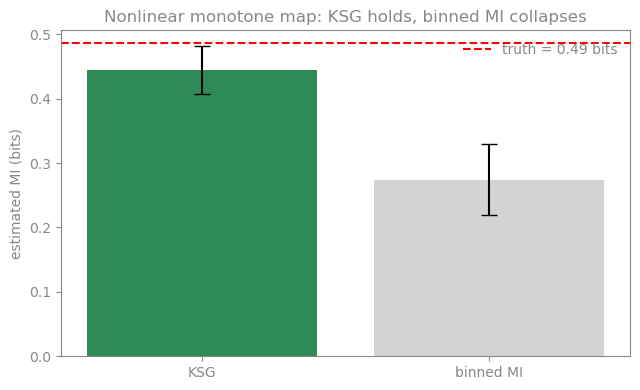

In [4]:
truth = true_gaussian_mi_bits(0.7)
ksg, binned = [], []
for s in range(15):
    r = np.random.default_rng(s)
    z = r.standard_normal(1000)
    x = 0.7 * z + np.sqrt(1 - 0.49) * r.standard_normal(1000)
    y = z ** 3                                   # monotone -> MI preserved
    ksg.append(ksg_mutual_information(x, y) / LOG2)
    binned.append(calculate_mutual_information(x, y) / LOG2)
ksg, binned = np.array(ksg), np.array(binned)
rmse = lambda a: np.sqrt(np.mean((a - truth) ** 2))
print(f"true MI (invariant under the monotone map) = {truth:.3f} bits")
print(f"KSG   : mean = {ksg.mean():.3f}   RMSE = {rmse(ksg):.3f}")
print(f"binned: mean = {binned.mean():.3f}   RMSE = {rmse(binned):.3f}   (badly underestimated)")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(["KSG", "binned MI"], [ksg.mean(), binned.mean()],
       yerr=[ksg.std(), binned.std()], color=["seagreen", "lightgray"], capsize=6)
ax.axhline(truth, color="red", ls="--", label=f"truth = {truth:.2f} bits")
ax.set_ylabel("estimated MI (bits)")
ax.set_title("Nonlinear monotone map: KSG holds, binned MI collapses")
ax.legend()
plt.tight_layout(); plt.show()

## 3. Distance correlation as a nonlinear screen

Consider a purely nonlinear, **non-monotone** relationship $y = x^2$. Pearson
correlation is near zero and would call the pair independent. Distance correlation
is built to be zero only under true independence, so it flags the dependence, and
KSG mutual information confirms it.

In [5]:
rows = []
for s in range(5):
    r = np.random.default_rng(s)
    x = r.standard_normal(500)
    y = x ** 2 + 0.1 * r.standard_normal(500)
    rows.append({
        "seed": s,
        "Pearson": np.corrcoef(x, y)[0, 1],
        "distance corr": distance_correlation(x, y),
        "KSG MI (bits)": ksg_mutual_information(x, y) / LOG2,
    })
pd.DataFrame(rows).set_index("seed").round(3)

,Pearson,distance corr,KSG MI (bits)
seed,,,
0,-0.135,0.528,2.614
1,-0.017,0.546,2.287
2,0.032,0.527,2.491
3,0.023,0.535,2.522
4,-0.058,0.542,2.482


## Takeaways

- **Prefer KSG over binned MI on short, noisy, or nonlinear/heavy-tailed samples**:
  on a nonlinear-monotone problem KSG's RMSE is a fraction of the binned estimator's,
  because it uses adaptive $k$-NN distances rather than an arbitrary grid.
- KSG is essentially **unbiased on linear dependence** and **converges to binned**
  on large near-linear samples, so there is no free lunch in the easy regime.
- Use **distance correlation** as a parameter-free nonlinear screen: it catches
  dependence that Pearson correlation misses entirely (e.g. $y = x^2$).

`calculate_mutual_information` is the binned baseline; `ksg_mutual_information` and
`distance_correlation` come from `RiskLabAI.data.distance`.